# LAB 5 — Notebook 02: Classification Paradigm
## QoE Prediction from QoS Data | EEF606 | University of Buea

---
**Prerequisite:** Run `lab5_00_data_generator.ipynb` first.

## Why Classification is the SECOND way to frame QoE

Imagine a network operations dashboard with a traffic light: green, yellow, red.
An engineer monitoring 10,000 active sessions does not need to know that one
session has exactly MOS=3.73 — they need to know **'is this session fine, or in trouble?'**

Classification answers: *Given network conditions, is this session Poor, Fair, Good, or Excellent?*

This is the SAME data as the regression notebook, but framed as a different problem.
This is the core lesson of the entire lab series: **the same data can be phrased as
different problems, and the right phrasing depends on what decision you need to make.**

## The 2 Models We Test
| Model | Core Idea | Why chosen |
|-------|-----------|------------|
| **Random Forest** | 100 trees, majority vote | Strong baseline, handles 4-class problems well |
| **Gradient Boosting (Hist)** | Sequential error correction | Often the best for structured tabular data |

## Why 4 Classes is Harder Than 2
In Lab 1, fraud detection was binary (fraud / not fraud). Here we have 4 classes
(Poor / Fair / Good / Excellent). Multi-class problems are harder because the
model can confuse ADJACENT classes (Fair vs Good) much more easily than
distant ones (Poor vs Excellent). The confusion matrix will show this pattern clearly.

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.ensemble         import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       f1_score, accuracy_score,
                                       ConfusionMatrixDisplay)

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True, 'grid.alpha': 0.4
})
SEED = 42
CLASS_ORDER = ['Poor', 'Fair', 'Good', 'Excellent']
CLASS_COLORS = ['#EF5350', '#FF9800', '#66BB6A', '#42A5F5']
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data and Check Class Balance
#
# WHY CHECK CLASS BALANCE FIRST (same lesson as Lab 1):
# Unlike fraud detection where one class was rare (1.3%),
# here our QoE labels may be more balanced because we
# designed the MOS formula to spread realistically across
# the range. But we NEVER assume — we always verify.
# ══════════════════════════════════════════════════════════
df = pd.read_csv('qoe_dataset.csv')
print(f'Loaded: {df.shape[0]:,} rows')

class_counts = df['qoe_label'].value_counts()[CLASS_ORDER]
print('\nClass distribution:')
for cls, cnt in class_counts.items():
    print(f'  {cls:<12}: {cnt:>8,} ({cnt/len(df)*100:.1f}%)')

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance ratio (largest:smallest): {imbalance_ratio:.1f}:1')
print('→ ' + ('Reasonably balanced — accuracy is meaningful here'
               if imbalance_ratio < 5 else
               'Imbalanced — use F1, not accuracy, as primary metric'))

Loaded: 1,000,000 rows

Class distribution:
  Poor        :   52,355 (5.2%)
  Fair        :   82,332 (8.2%)
  Good        :  524,172 (52.4%)
  Excellent   :  341,141 (34.1%)

Imbalance ratio (largest:smallest): 10.0:1
→ Imbalanced — use F1, not accuracy, as primary metric


In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — Prepare Features and Target
#
# WHY LabelEncoder FOR THE TARGET:
# sklearn classifiers need numeric targets internally.
# LabelEncoder converts 'Poor'→0, 'Fair'→1, 'Good'→2,
# 'Excellent'→3. We must specify the ORDER explicitly
# (classes_ attribute) so 0,1,2,3 follows the natural
# quality ordering — not alphabetical, which would put
# 'Excellent' before 'Fair' and confuse interpretation.
# ══════════════════════════════════════════════════════════
df_enc = pd.get_dummies(df.drop(columns=['mos_score']),
                         columns=['resolution','connection_type'],
                         drop_first=True, dtype=int)

le = LabelEncoder()
le.fit(CLASS_ORDER)  # force the natural order
df_enc['qoe_label_encoded'] = le.transform(df_enc['qoe_label'])

X = df_enc.drop(columns=['qoe_label', 'qoe_label_encoded'])
y = df_enc['qoe_label_encoded']

print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Features: {X.shape[1]} columns')

Label encoding: {np.str_('Excellent'): np.int64(0), np.str_('Fair'): np.int64(1), np.str_('Good'): np.int64(2), np.str_('Poor'): np.int64(3)}
Features: 14 columns


In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Train/Test Split + Scaling
#
# WHY stratify=y:
# Ensures all 4 classes appear in the same proportion
# in both train and test sets. Without this, a random
# split might put very few 'Poor' examples in the test
# set, making that class's metrics unreliable.
# ══════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler  = RobustScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test : {X_test.shape[0]:,} rows')
print(f'\nTest set class distribution (should match overall):')
for i, cls in enumerate(CLASS_ORDER):
    print(f'  {cls:<12}: {(y_test==i).sum():,} ({(y_test==i).mean()*100:.1f}%)')

Train: 800,000 rows
Test : 200,000 rows

Test set class distribution (should match overall):
  Poor        : 68,228 (34.1%)
  Fair        : 16,466 (8.2%)
  Good        : 104,835 (52.4%)
  Excellent   : 10,471 (5.2%)


In [5]:
# ══════════════════════════════════════════════════════════
# CELL 5 — Model 1: Random Forest (Multi-class)
#
# HOW RANDOM FOREST HANDLES 4 CLASSES (not just 2):
# Each tree, at its leaf nodes, doesn't just say 'fraud'
# or 'not fraud' — it outputs a probability distribution
# across all 4 classes: e.g. [0.1, 0.2, 0.6, 0.1].
# The forest averages these distributions across all
# 100 trees, then picks the class with highest average
# probability as the final prediction.
#
# WHY class_weight='balanced' STILL MATTERS:
# Even with 4 reasonably balanced classes, this setting
# ensures no class is systematically ignored.
# ══════════════════════════════════════════════════════════
print('Training Random Forest (multi-class)...')
import time
t0 = time.time()

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
rf_clf.fit(X_tr_sc, y_train)
rf_pred = rf_clf.predict(X_te_sc)

print(f'Training time: {time.time()-t0:.1f}s')
print(f'\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=CLASS_ORDER))

Training Random Forest (multi-class)...
Training time: 83.1s

Classification Report:
              precision    recall  f1-score   support

        Poor       0.78      0.84      0.81     68228
        Fair       0.70      0.92      0.80     16466
        Good       0.87      0.78      0.83    104835
   Excellent       0.98      0.97      0.98     10471

    accuracy                           0.83    200000
   macro avg       0.83      0.88      0.85    200000
weighted avg       0.83      0.83      0.83    200000



In [6]:
# ══════════════════════════════════════════════════════════
# CELL 6 — Model 2: Hist Gradient Boosting (Multi-class)
#
# WHY HistGradientBoosting NOT REGULAR GradientBoosting:
# Same lesson from Lab 1 — regular GBM is sequential and
# slow on large datasets. HistGBM bins continuous features
# into histograms first, making each split decision much
# faster. On 1M rows this matters enormously.
#
# HOW BOOSTING DIFFERS FROM RANDOM FOREST HERE:
# Random Forest trees are trained INDEPENDENTLY and in
# PARALLEL. HistGBM trees are trained SEQUENTIALLY — each
# new tree focuses on correcting the mistakes of all
# previous trees combined. This often gives better accuracy
# but takes longer per-tree (though still fast due to
# histogram binning).
# ══════════════════════════════════════════════════════════
print('Training Hist Gradient Boosting (multi-class)...')
t0 = time.time()

hgb_clf = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=SEED
)
hgb_clf.fit(X_tr_sc, y_train)
hgb_pred = hgb_clf.predict(X_te_sc)

print(f'Training time: {time.time()-t0:.1f}s')
print(f'\nClassification Report:')
print(classification_report(y_test, hgb_pred, target_names=CLASS_ORDER))

Training Hist Gradient Boosting (multi-class)...
Training time: 39.8s

Classification Report:
              precision    recall  f1-score   support

        Poor       0.82      0.78      0.80     68228
        Fair       0.86      0.82      0.84     16466
        Good       0.84      0.87      0.86    104835
   Excellent       0.98      0.97      0.98     10471

    accuracy                           0.84    200000
   macro avg       0.88      0.86      0.87    200000
weighted avg       0.84      0.84      0.84    200000



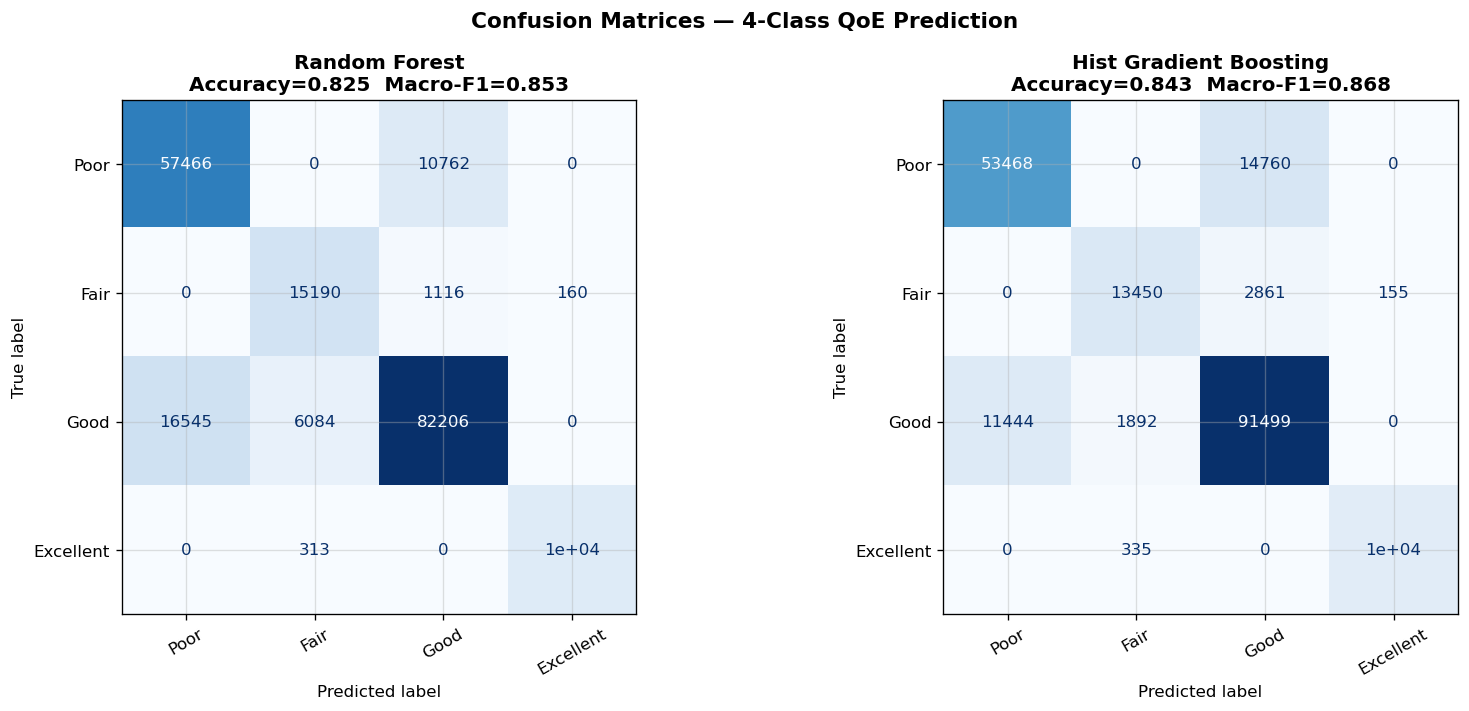

Random Forest: Adjacent-class errors=7,200  Severe errors=27,780
Hist Gradient Boosting: Adjacent-class errors=4,753  Severe errors=26,694


In [7]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Confusion Matrices: Where Do Models Get Confused?
#
# HOW TO READ A 4×4 CONFUSION MATRIX:
# Rows = actual class. Columns = predicted class.
# Diagonal = correct predictions (want this HIGH).
# Off-diagonal near the diagonal (e.g. Fair predicted as
# Good) = the model confused ADJACENT classes — this is
# expected and less serious.
# Off-diagonal far from diagonal (e.g. Poor predicted as
# Excellent) = SERIOUS error — this should be rare.
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred),
                                    ('Hist Gradient Boosting', hgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    ax.set_title(f'{name}\nAccuracy={acc:.3f}  Macro-F1={f1m:.3f}', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — 4-Class QoE Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clf_01_confusion_matrices.png', bbox_inches='tight')
plt.show()

# Quantify adjacent vs severe errors
for name, pred in [('Random Forest', rf_pred), ('Hist Gradient Boosting', hgb_pred)]:
    cm = confusion_matrix(y_test, pred)
    n = len(CLASS_ORDER)
    adjacent_errors = sum(cm[i][j] for i in range(n) for j in range(n)
                          if abs(i-j) == 1)
    severe_errors   = sum(cm[i][j] for i in range(n) for j in range(n)
                          if abs(i-j) >= 2)
    print(f'{name}: Adjacent-class errors={adjacent_errors:,}  Severe errors={severe_errors:,}')

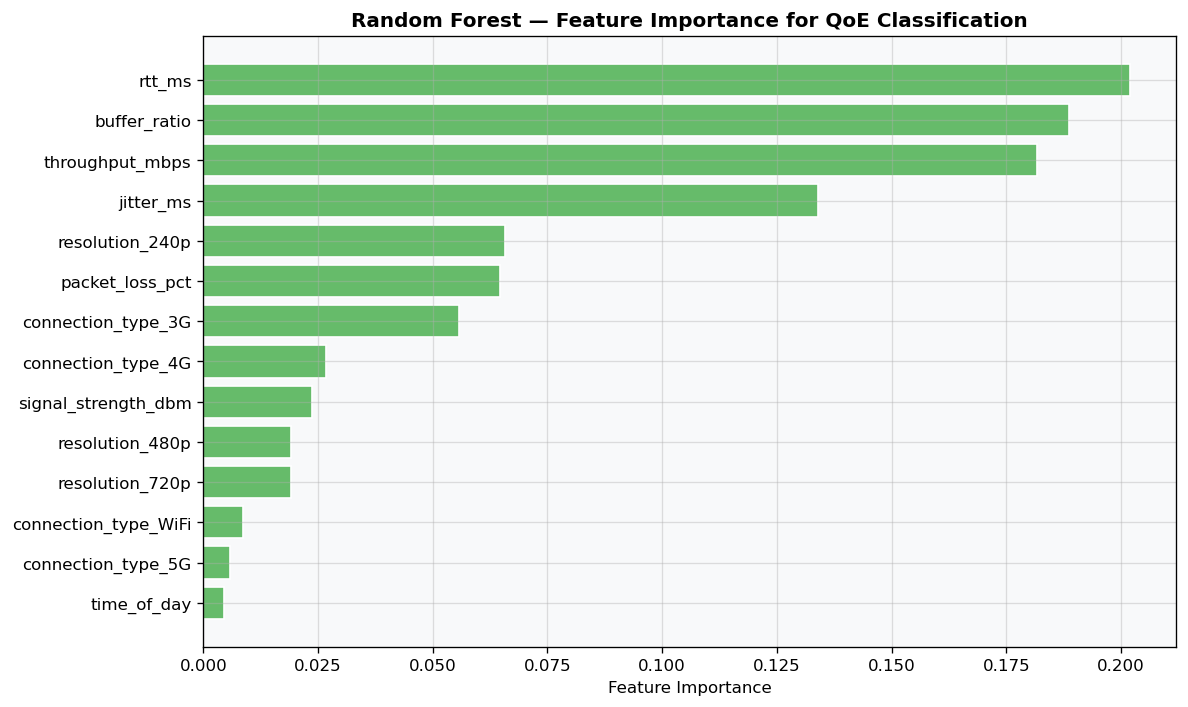

Top 5 features for classification:
  rtt_ms                         0.2019
  buffer_ratio                   0.1886
  throughput_mbps                0.1817
  jitter_ms                      0.1339
  resolution_240p                0.0657


In [8]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Feature Importance Comparison
# ══════════════════════════════════════════════════════════
rf_imp  = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_imp.index[::-1][-15:], rf_imp.values[::-1][-15:],
        color='#66BB6A', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance for QoE Classification',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clf_02_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features for classification:')
for feat, imp in rf_imp.head(5).items():
    print(f'  {feat:<30} {imp:.4f}')

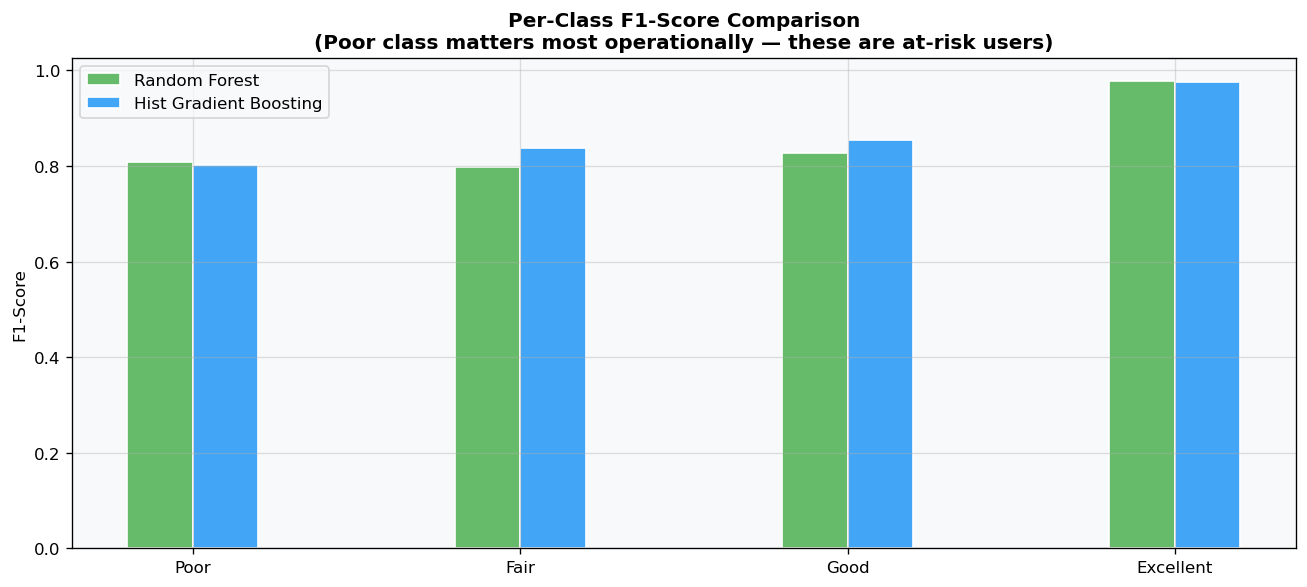

In [9]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Per-Class Performance Visualisation
#
# WHY LOOK AT EACH CLASS SEPARATELY:
# A single 'accuracy' number can hide problems. A model
# might be excellent at predicting 'Good' (the most common
# class) but terrible at predicting 'Poor' (rare but most
# operationally important — these are the users about to
# complain or churn).
# ══════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score

per_class_data = []
for name, pred in [('Random Forest', rf_pred), ('Hist Gradient Boosting', hgb_pred)]:
    for i, cls in enumerate(CLASS_ORDER):
        per_class_data.append({
            'Model': name, 'Class': cls,
            'Precision': precision_score(y_test, pred, labels=[i], average='micro'),
            'Recall':    recall_score(y_test, pred, labels=[i], average='micro'),
            'F1':        f1_score(y_test, pred, labels=[i], average='micro'),
        })

per_class_df = pd.DataFrame(per_class_data)

fig, ax = plt.subplots(figsize=(11, 5))
width = 0.2
x = np.arange(len(CLASS_ORDER))
for i, (name, color) in enumerate([('Random Forest', '#66BB6A'),
                                     ('Hist Gradient Boosting', '#42A5F5')]):
    subset = per_class_df[per_class_df['Model']==name].set_index('Class').loc[CLASS_ORDER]
    ax.bar(x + i*width, subset['F1'], width, label=name, color=color, edgecolor='white')

ax.set_xticks(x + width/2)
ax.set_xticklabels(CLASS_ORDER)
ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score Comparison\n'
             '(Poor class matters most operationally — these are at-risk users)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_clf_03_per_class_f1.png', bbox_inches='tight')
plt.show()

In [10]:
# ══════════════════════════════════════════════════════════
# CELL 10 — Save Models + Summary
# ══════════════════════════════════════════════════════════
import joblib
joblib.dump(rf_clf,  'model_rf_classifier.pkl')
joblib.dump(hgb_clf, 'model_hgb_classifier.pkl')
joblib.dump(le,      'label_encoder.pkl')

print('╔' + '═'*60 + '╗')
print('║{:^60}║'.format('CLASSIFICATION SUMMARY'))
print('╠' + '═'*60 + '╣')
for name, pred in [('Random Forest', rf_pred), ('Hist Gradient Boosting', hgb_pred)]:
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    print(f'║  {name:<30}  Acc={acc:.4f}  Macro-F1={f1m:.4f}  ║')
print('╠' + '═'*60 + '╣')
insights = [
    'Classification turns continuous MOS into operational tiers',
    'Adjacent-class confusion (Fair↔Good) is expected & less severe',
    'Buffer ratio and packet loss drive classification too',
    'Poor class F1 matters most — these are at-risk users',
    'Compare to Notebook 01: same data, different question asked',
]
for ins in insights:
    print(f'║  → {ins:<56}║')
print('╚' + '═'*60 + '╝')
print('\n→ Next: lab5_03_clustering.ipynb')

╔════════════════════════════════════════════════════════════╗
║                   CLASSIFICATION SUMMARY                   ║
╠════════════════════════════════════════════════════════════╣
║  Random Forest                   Acc=0.8251  Macro-F1=0.8525  ║
║  Hist Gradient Boosting          Acc=0.8428  Macro-F1=0.8679  ║
╠════════════════════════════════════════════════════════════╣
║  → Classification turns continuous MOS into operational tiers║
║  → Adjacent-class confusion (Fair↔Good) is expected & less severe║
║  → Buffer ratio and packet loss drive classification too   ║
║  → Poor class F1 matters most — these are at-risk users    ║
║  → Compare to Notebook 01: same data, different question asked║
╚════════════════════════════════════════════════════════════╝

→ Next: lab5_03_clustering.ipynb
